In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line.strip()))
    return pd.DataFrame(data)

train_df = load_jsonl('data/train.jsonl')
valid_df = load_jsonl('data/valid.jsonl')
test_df = load_jsonl('data/test.jsonl')

print(f"Train: {len(train_df)} samples")
print(f"Valid: {len(valid_df)} samples")
print(f"Test:  {len(test_df)} samples")

Train: 788 samples
Valid: 85 samples
Test:  84 samples


In [3]:
train_df.head()

,id,vul_id,file,method,version,text,labels,code_hash,is_test
0,VUL4J-1:755dc4415452,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,deserialze,vulnerable,"@SuppressWarnings({ ""unchecked"", ""rawtypes"" })...",1,755dc44154520f77ee167ba430ee1954d2fcb69a,False
1,VUL4J-1:890f0a980a17,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,deserialze,fixed,"@SuppressWarnings({ ""unchecked"", ""rawtypes"" })...",0,890f0a980a17af87d2591dfe5e5938dbdd3092a1,False
2,VUL4J-1:d6a7e92c0d6f,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,toObjectArray,vulnerable_other,"@SuppressWarnings(""unchecked"")\n private <T...",0,d6a7e92c0d6f526d5594c7eb2822862a8a7e9852,False
3,VUL4J-1:fb7110dbae02,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,ObjectArrayCodec,vulnerable_other,public ObjectArrayCodec(){\n },0,fb7110dbae027bc8a2c6a11c96cb30ab8f634403,False
4,VUL4J-1:bfa8c049d2c9,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,getFastMatchToken,vulnerable_other,public int getFastMatchToken() {\n retu...,0,bfa8c049d2c9c84b70fd0bd261aa44669789c7ef,False


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         788 non-null    str  
 1   vul_id     788 non-null    str  
 2   file       788 non-null    str  
 3   method     788 non-null    str  
 4   version    788 non-null    str  
 5   text       788 non-null    str  
 6   labels     788 non-null    int64
 7   code_hash  788 non-null    str  
 8   is_test    788 non-null    bool 
dtypes: bool(1), int64(1), str(7)
memory usage: 565.5 KB


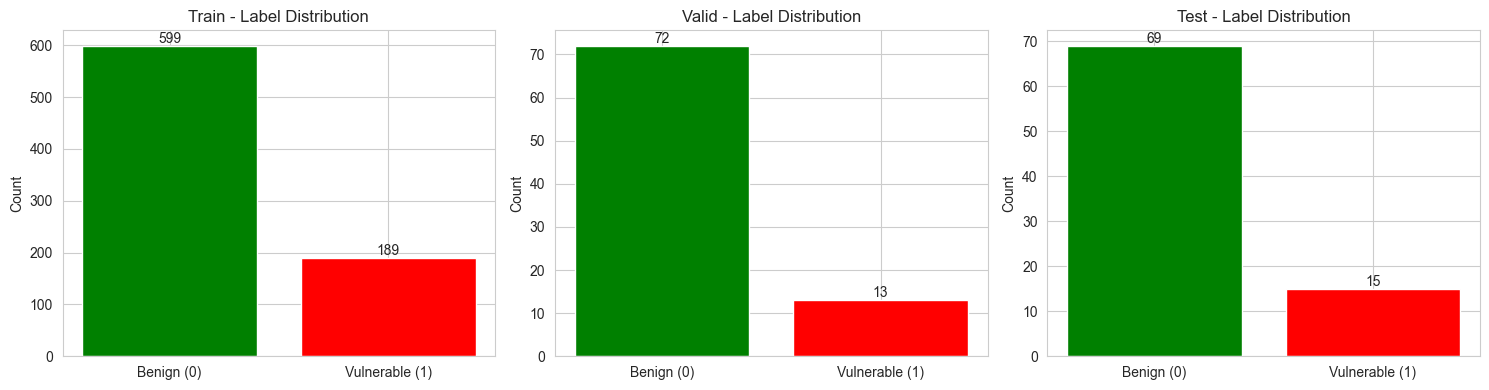

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (df, name) in enumerate([(train_df, 'Train'), (valid_df, 'Valid'), (test_df, 'Test')]):
    labels_count = df['labels'].value_counts().sort_index()
    axes[idx].bar(['Benign (0)', 'Vulnerable (1)'], labels_count.values, color=['green', 'red'])
    axes[idx].set_title(f'{name} - Label Distribution')
    axes[idx].set_ylabel('Count')
    for i, v in enumerate(labels_count.values):
        axes[idx].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [6]:
summary = pd.DataFrame({
    'Dataset': ['Train', 'Valid', 'Test'],
    'Total': [len(train_df), len(valid_df), len(test_df)],
    'Vulnerable': [train_df['labels'].sum(), valid_df['labels'].sum(), test_df['labels'].sum()],
    'Benign': [(train_df['labels'] == 0).sum(), (valid_df['labels'] == 0).sum(), (test_df['labels'] == 0).sum()]
})
summary['Vuln_Ratio'] = (summary['Vulnerable'] / summary['Total'] * 100).round(2)
summary

,Dataset,Total,Vulnerable,Benign,Vuln_Ratio
0,Train,788,189,599,23.98
1,Valid,85,13,72,15.29
2,Test,84,15,69,17.86


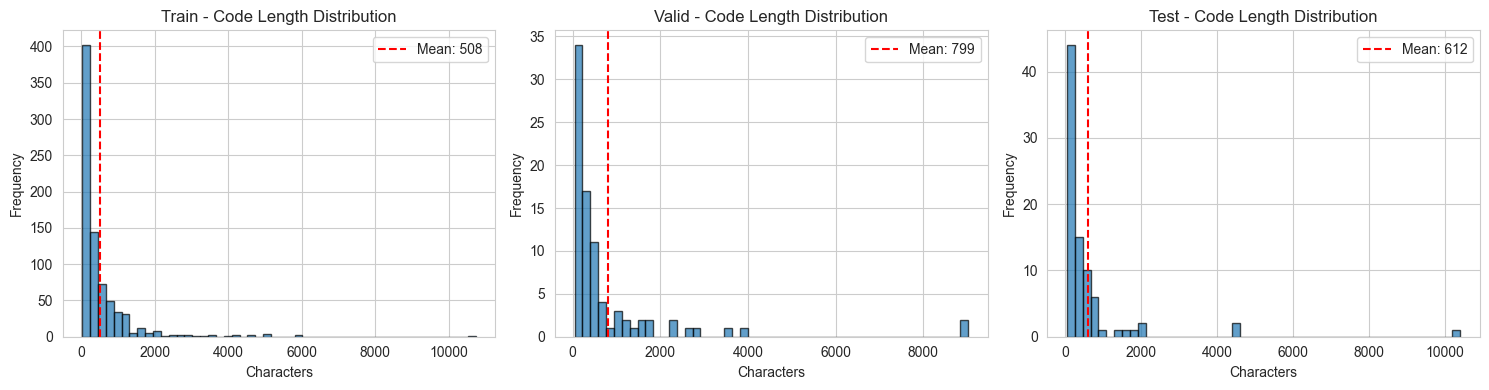

In [7]:
train_df['text_length'] = train_df['text'].str.len()
valid_df['text_length'] = valid_df['text'].str.len()
test_df['text_length'] = test_df['text'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (df, name) in enumerate([(train_df, 'Train'), (valid_df, 'Valid'), (test_df, 'Test')]):
    axes[idx].hist(df['text_length'], bins=50, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{name} - Code Length Distribution')
    axes[idx].set_xlabel('Characters')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df['text_length'].mean(), color='r', linestyle='--', label=f'Mean: {df["text_length"].mean():.0f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [8]:
length_stats = pd.DataFrame({
    'Dataset': ['Train', 'Valid', 'Test'],
    'Mean': [train_df['text_length'].mean(), valid_df['text_length'].mean(), test_df['text_length'].mean()],
    'Median': [train_df['text_length'].median(), valid_df['text_length'].median(), test_df['text_length'].median()],
    'Min': [train_df['text_length'].min(), valid_df['text_length'].min(), test_df['text_length'].min()],
    'Max': [train_df['text_length'].max(), valid_df['text_length'].max(), test_df['text_length'].max()],
    'Std': [train_df['text_length'].std(), valid_df['text_length'].std(), test_df['text_length'].std()]
})
length_stats.round(2)

,Dataset,Mean,Median,Min,Max,Std
0,Train,508.29,233.0,29,10732,825.11
1,Valid,798.60,331.0,44,9023,1501.74
2,Test,611.74,238.0,56,10398,1318.26


C:\Users\Admin\AppData\Local\Temp\ipykernel_8288\734227028.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([benign, vuln], labels=['Benign', 'Vulnerable'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_8288\734227028.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([benign, vuln], labels=['Benign', 'Vulnerable'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_8288\734227028.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([benign, vuln], labels=['Benign', 'Vulnerable'])


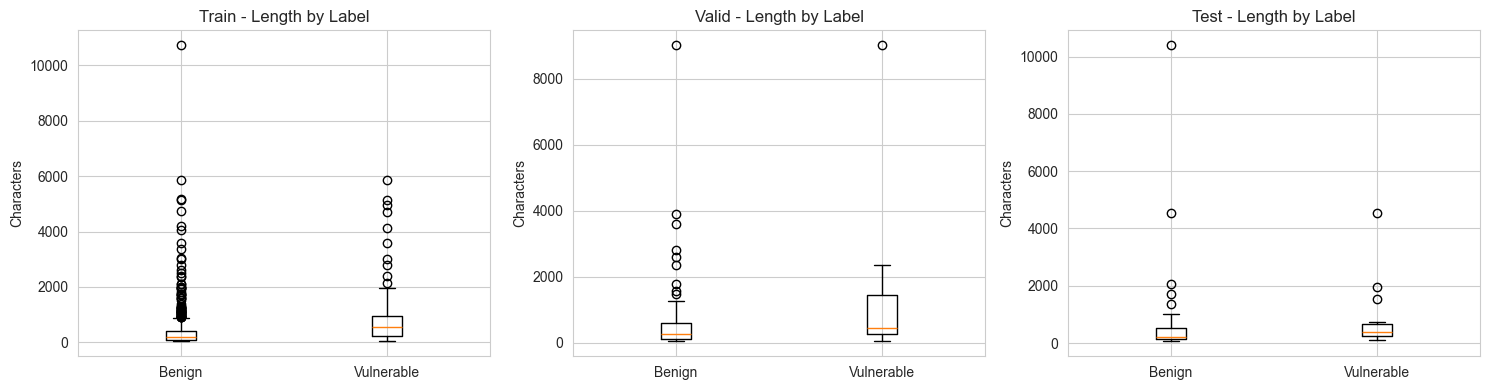

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (df, name) in enumerate([(train_df, 'Train'), (valid_df, 'Valid'), (test_df, 'Test')]):
    vuln = df[df['labels'] == 1]['text_length']
    benign = df[df['labels'] == 0]['text_length']
    
    axes[idx].boxplot([benign, vuln], labels=['Benign', 'Vulnerable'])
    axes[idx].set_title(f'{name} - Length by Label')
    axes[idx].set_ylabel('Characters')

plt.tight_layout()
plt.show()

In [10]:
print(f"Unique vul_ids in train: {train_df['vul_id'].nunique()}")
print(f"Unique vul_ids in valid: {valid_df['vul_id'].nunique()}")
print(f"Unique vul_ids in test:  {test_df['vul_id'].nunique()}")

train_vul_ids = set(train_df['vul_id'])
valid_vul_ids = set(valid_df['vul_id'])
test_vul_ids = set(test_df['vul_id'])

print(f"\nOverlap train-valid: {len(train_vul_ids & valid_vul_ids)}")
print(f"Overlap train-test:  {len(train_vul_ids & test_vul_ids)}")
print(f"Overlap valid-test:  {len(valid_vul_ids & test_vul_ids)}")

Unique vul_ids in train: 64
Unique vul_ids in valid: 8
Unique vul_ids in test:  8

Overlap train-valid: 0
Overlap train-test:  0
Overlap valid-test:  0


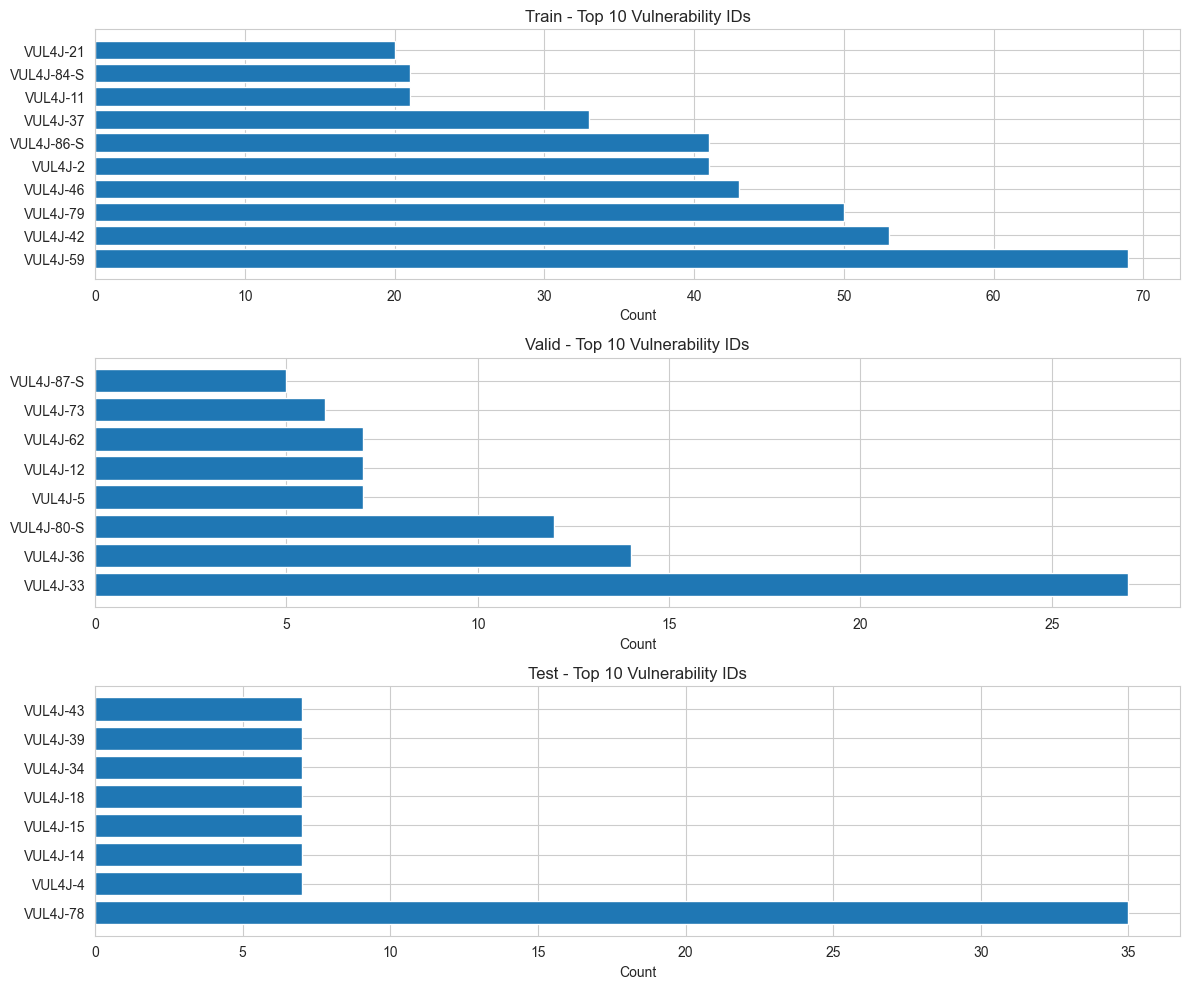

In [11]:
top_vul_train = train_df['vul_id'].value_counts().head(10)
top_vul_valid = valid_df['vul_id'].value_counts().head(10)
top_vul_test = test_df['vul_id'].value_counts().head(10)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].barh(top_vul_train.index.astype(str), top_vul_train.values)
axes[0].set_title('Train - Top 10 Vulnerability IDs')
axes[0].set_xlabel('Count')

axes[1].barh(top_vul_valid.index.astype(str), top_vul_valid.values)
axes[1].set_title('Valid - Top 10 Vulnerability IDs')
axes[1].set_xlabel('Count')

axes[2].barh(top_vul_test.index.astype(str), top_vul_test.values)
axes[2].set_title('Test - Top 10 Vulnerability IDs')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [12]:
print(f"Is test files in train: {train_df['is_test'].sum()}")
print(f"Is test files in valid: {valid_df['is_test'].sum()}")
print(f"Is test files in test:  {test_df['is_test'].sum()}")

Is test files in train: 0
Is test files in valid: 0
Is test files in test:  0


In [13]:
version_dist = pd.DataFrame({
    'Train': train_df['version'].value_counts(),
    'Valid': valid_df['version'].value_counts(),
    'Test': test_df['version'].value_counts()
}).fillna(0).astype(int)

version_dist

,Train,Valid,Test
version,,,
vulnerable_other,511,59,55
vulnerable,189,13,15
fixed,88,13,14


In [14]:
print("Duplicate code_hash in train:", train_df['code_hash'].duplicated().sum())
print("Duplicate code_hash in valid:", valid_df['code_hash'].duplicated().sum())
print("Duplicate code_hash in test:", test_df['code_hash'].duplicated().sum())

all_hashes = set(train_df['code_hash']) | set(valid_df['code_hash']) | set(test_df['code_hash'])
print(f"\nTotal unique code samples across all splits: {len(all_hashes)}")

Duplicate code_hash in train: 0
Duplicate code_hash in valid: 0
Duplicate code_hash in test: 0

Total unique code samples across all splits: 957
